# Trading Data Analysis and Linear Price Model

This notebook loads round-1 price CSV files, visualizes market behavior, and trains a linear regression model in scikit-learn to predict `mid_price`.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

In [3]:
# Resolve the data directory whether notebook runs from project root or notebooks/.
candidate_dirs = [Path('data/ROUND_1'), Path('../data/ROUND_1')]
data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError('Could not find data/ROUND_1 directory.')

price_files = sorted(data_dir.glob('prices_round_1_day_*.csv'))
if not price_files:
    raise FileNotFoundError('No prices_round_1_day_*.csv files found.')

prices = pd.concat((pd.read_csv(f, sep=';') for f in price_files), ignore_index=True)
prices["combinedtimestamp"] = (prices["day"] * 1_000_000 + prices["timestamp"]).astype('int64')


In [4]:
print(f'Loaded {len(price_files)} files from: {data_dir}')
print(f'Rows: {len(prices):,} | Columns: {prices.shape[1]}')
print('Products:', sorted(prices['product'].dropna().unique()))
prices.describe(include='all').transpose().head(20)

Loaded 3 files from: ..\data\ROUND_1
Rows: 60,000 | Columns: 18
Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
day,60000.0,NaN,NaN,NaN,-1.0,0.816503,-2.0,-2.0,-1.0,0.0,0.0
timestamp,60000.0,NaN,NaN,NaN,499950.0,288677.538808,0.0,249975.0,499950.0,749925.0,999900.0
product,60000,2,INTARIAN_PEPPER_ROOT,30000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bid_price_1,57580.0,NaN,NaN,NaN,10743.208475,968.979084,9976.0,9992.0,10006.0,11496.0,12993.0
bid_volume_1,57580.0,NaN,NaN,NaN,12.833293,4.976882,2.0,10.0,12.0,14.0,30.0
bid_price_2,39009.0,NaN,NaN,NaN,10737.361224,967.923166,9976.0,9990.0,10002.0,11487.0,12989.0
bid_volume_2,39009.0,NaN,NaN,NaN,22.051245,4.509846,2.0,19.0,22.0,25.0,30.0
bid_price_3,1224.0,NaN,NaN,NaN,10559.825163,914.589148,9976.0,9988.0,9993.0,10976.5,12979.0
bid_volume_3,1224.0,NaN,NaN,NaN,23.168301,4.063008,8.0,21.0,23.0,26.0,30.0
ask_price_1,57649.0,NaN,NaN,NaN,10758.551666,968.405273,9984.0,10009.0,10021.0,11509.0,13010.0


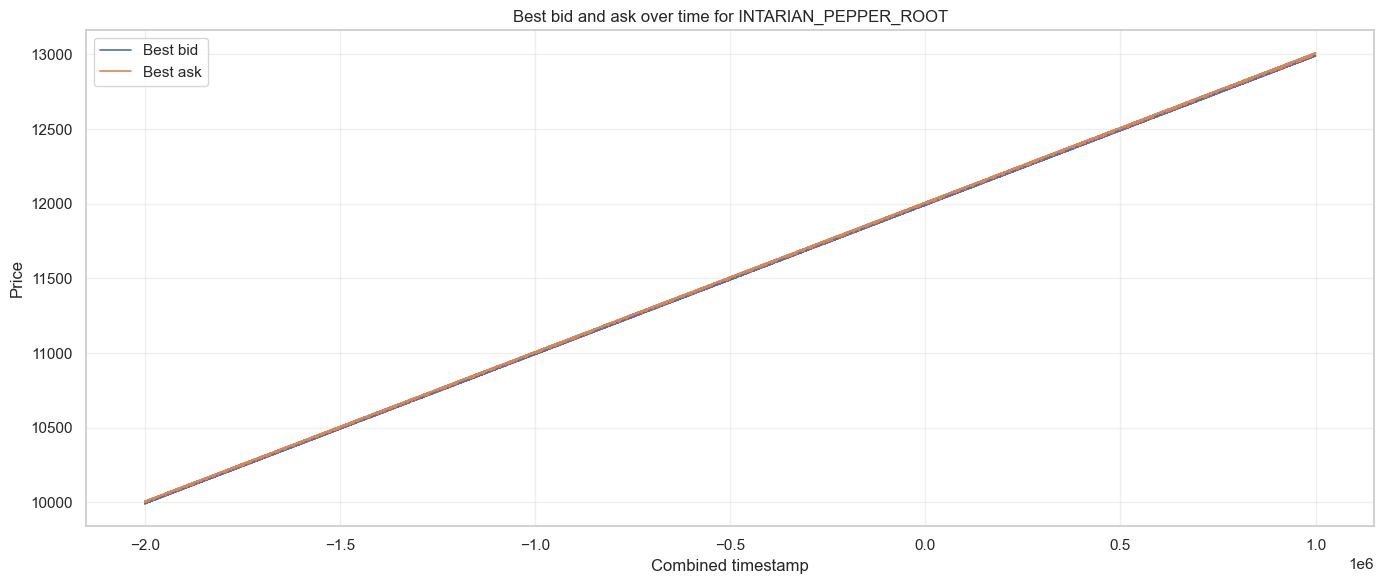

In [5]:
top_product = prices['product'].value_counts().idxmax()
product_prices = prices.loc[prices['product'] == top_product].sort_values('combinedtimestamp')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(product_prices['combinedtimestamp'], product_prices['bid_price_1'], label='Best bid', linewidth=1.2)
ax.plot(product_prices['combinedtimestamp'], product_prices['ask_price_1'], label='Best ask', linewidth=1.2)
ax.set_title(f'Best bid and ask over time for {top_product}')
ax.set_xlabel('Combined timestamp')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# Fit a simple linear model from combined timestamp to best bid and best ask for the same product.
model_data = product_prices.dropna(subset=['combinedtimestamp', 'bid_price_1', 'ask_price_1']).copy()
X = model_data[['combinedtimestamp']]
y = model_data[['bid_price_1', 'ask_price_1']]

split_index = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

price_model = LinearRegression()
price_model.fit(X_train, y_train)
price_predictions = price_model.predict(X_test)

prediction_frame = pd.DataFrame(
    price_predictions,
    columns=['pred_bid_price_1', 'pred_ask_price_1'],
    index=y_test.index,
)

bid_mae = mean_absolute_error(y_test['bid_price_1'], prediction_frame['pred_bid_price_1'])
ask_mae = mean_absolute_error(y_test['ask_price_1'], prediction_frame['pred_ask_price_1'])
bid_rmse = mean_squared_error(y_test['bid_price_1'], prediction_frame['pred_bid_price_1']) ** 0.5
ask_rmse = mean_squared_error(y_test['ask_price_1'], prediction_frame['pred_ask_price_1']) ** 0.5
bid_r2 = r2_score(y_test['bid_price_1'], prediction_frame['pred_bid_price_1'])
ask_r2 = r2_score(y_test['ask_price_1'], prediction_frame['pred_ask_price_1'])

print(f'Linear model for {top_product}')
print(f'Bid  - MAE: {bid_mae:,.3f} | RMSE: {bid_rmse:,.3f} | R2: {bid_r2:.4f}')
print(f'Ask  - MAE: {ask_mae:,.3f} | RMSE: {ask_rmse:,.3f} | R2: {ask_r2:.4f}')


Linear model for INTARIAN_PEPPER_ROOT
Bid  - MAE: 0.955 | RMSE: 1.842 | R2: 0.9999
Ask  - MAE: 0.988 | RMSE: 2.005 | R2: 0.9999


In [10]:
price_model.coef_, price_model.intercept_

(array([[0.00099948],
        [0.00100055]]),
 array([11993.20222286, 12006.78338719]))